In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import Perceptron
import warnings 
warnings.filterwarnings('ignore')

C:\Users\sawsu\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
dt=pd.read_csv("placement.csv")

In [3]:
dt.sample(5)

,cgpa,resume_score,placed
63,8.65,7.58,1
33,8.43,7.73,1
89,5.99,7.49,0
20,5.80,8.06,0
87,5.62,5.05,0


In [4]:
dt.shape

(100, 3)

In [5]:
dt.isnull().sum()

cgpa            0
resume_score    0
placed          0
dtype: int64

In [6]:
dt.info

<bound method DataFrame.info of     cgpa  resume_score  placed
0   8.14          6.52       1
1   6.17          5.17       0
2   8.27          8.86       1
3   6.88          7.27       1
4   7.52          7.30       1
..   ...           ...     ...
95  6.33          6.38       0
96  8.23          7.76       1
97  6.65          7.78       0
98  8.14          5.63       1
99  6.09          6.61       0

[100 rows x 3 columns]>

<Axes: xlabel='cgpa', ylabel='resume_score'>

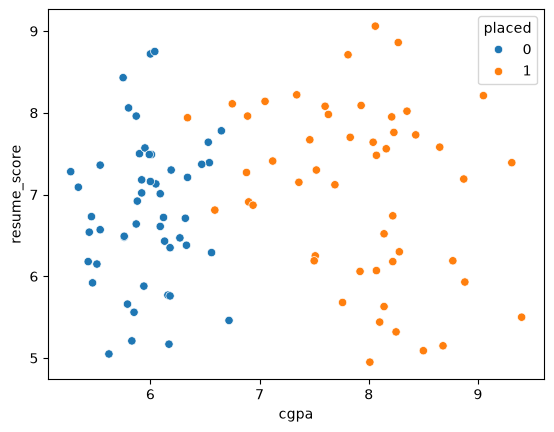

In [7]:
sns.scatterplot(x='cgpa',y='resume_score',hue='placed',data=dt)

In [8]:
x=dt.iloc[:,0:2]
y=dt.iloc[:,-1]

In [9]:
p=Perceptron() 
p.fit(x,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [10]:
p.coef_  #weights(w1,w2)

array([[ 40.26, -36.  ]])

In [11]:
p.intercept_ #bias(b)

array([-25.])

<Axes: >

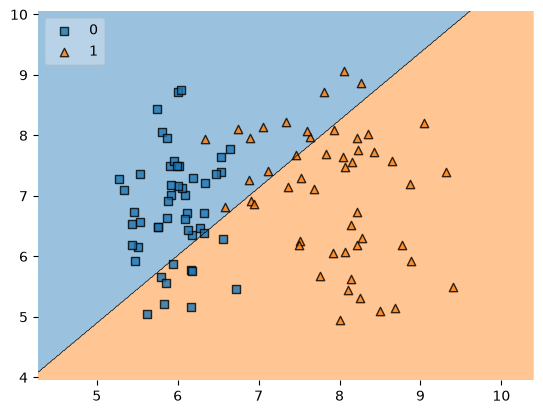

In [12]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values,y.values,clf=p,legend=2)

# Percetron-Trick

In [13]:
from sklearn.datasets import make_classification 
import numpy as np 
import matplotlib.pyplot as plt 
X,y=make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1,
                    class_sep=10, hypercube=False, random_state=41,)


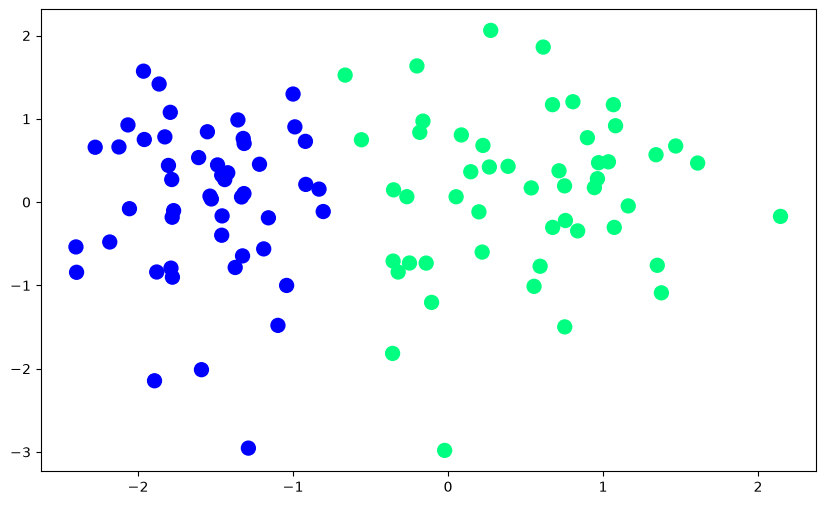

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [15]:
def perceptron(X,y): 
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    learning_rate=0.1
    for i in range(1000): 
        j=np.random.randint(0,100) 
        y_hat=step(np.dot(X[j],weights))
        weights=weights+learning_rate*(y[j]-y_hat)*X[j]
        return weights[0],weights[1:]
    

In [16]:
def step(z): 
    return 1 if z>0 else 0

In [17]:
intercept_,coef_=perceptron(X,y)

In [18]:
print(coef_)
print(intercept_)

[1. 1.]
1.0
